In [1]:
# Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 


sb.set() # set the default Seaborn style for graphics

from matplotlib import pyplot as plt, font_manager as fm
import math
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as rmse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import train_test_split 
from sklearn import metrics 
from sklearn.metrics import confusion_matrix 
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")


In [2]:
#Loading the data
df = pd.read_csv (r'/Users/huynhthuybaotram/Downloads/SCLM 479/Rebisco_Demand_Planning_2021_2026.csv', encoding='utf-8', sep=';')
df.head(50)

,Year,Month,Brand,Product Name,Pack Size,Volume (MT)
0,2021,1,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"174,31"
1,2021,2,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"152,76"
2,2021,3,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"112,24"
3,2021,4,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"113,25"
4,2021,5,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"111,76"
5,2021,6,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"113,3"
6,2021,7,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"113,58"
7,2021,8,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"125,86"
8,2021,9,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"137,83"
9,2021,10,Doowee Donut,Doowee Donut Chocolate,Single Pack (30g),"125,36"


In [3]:
# 0 EDA 
# Basic info
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1656 entries, 0 to 1655
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          1656 non-null   int64 
 1   Month         1656 non-null   int64 
 2   Brand         1656 non-null   object
 3   Product Name  1656 non-null   object
 4   Pack Size     1656 non-null   object
 5   Volume (MT)   1656 non-null   object
dtypes: int64(2), object(4)
memory usage: 77.8+ KB


Year            0
Month           0
Brand           0
Product Name    0
Pack Size       0
Volume (MT)     0
dtype: int64

In [1050]:
# 1. Chuẩn hóa dữ liệu số: Chuyển "174,31" thành 174.31 (thay dấu phẩy bằng dấu chấm) để Python hiểu đó là số thực (float)
df['Volume (MT)'] = (
    df['Volume (MT)']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# 2. Tạo cột Datetime: Gộp Năm và Tháng lại thành một cột thời gian chuẩn để làm Time Series
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01'
)

# 3. Sắp xếp dữ liệu: Đảm bảo dòng thời gian chạy liên tục từ cũ đến mới, không bị nhảy cóc
df = df.sort_values('Date')

# 4. Tổng hợp dữ liệu (Aggregation): Tính tổng sản lượng của tất cả 15 loại sản phẩm theo từng tháng
ts = (
    df
    .groupby('Date')['Volume (MT)']
    .sum()
    .asfreq('MS') # Ép tần suất dữ liệu là 'Month Start' (đầu mỗi tháng) để tránh mất dữ liệu khi dự báo
)


In [1052]:
ts

Date
2021-01-01    1746.86
2021-02-01    1472.00
2021-03-01    1283.12
2021-04-01    1284.09
2021-05-01    1234.27
2021-06-01    1093.91
2021-07-01    1086.54
2021-08-01    1270.64
2021-09-01    1556.06
2021-10-01    1420.63
2021-11-01    1501.57
2021-12-01    1626.89
2022-01-01    1973.99
2022-02-01    1657.92
2022-03-01    1431.51
2022-04-01    1443.27
2022-05-01    1381.02
2022-06-01    1220.78
2022-07-01    1224.67
2022-08-01    1430.72
2022-09-01    1720.22
2022-10-01    1591.88
2022-11-01    1691.71
2022-12-01    1852.83
2023-01-01    2188.63
2023-02-01    1840.67
2023-03-01    1593.28
2023-04-01    1587.44
2023-05-01    1525.83
2023-06-01    1352.00
2023-07-01    1358.00
2023-08-01    1580.13
2023-09-01    1913.69
2023-10-01    1761.97
2023-11-01    1883.12
2023-12-01    2049.53
2024-01-01    2120.67
2024-02-01    1775.86
2024-03-01    1551.64
2024-04-01    1545.89
2024-05-01    1479.67
2024-06-01    1317.08
2024-07-01    1305.96
2024-08-01    1524.43
2024-09-01    1860.99
2024-

In [637]:
# 5. Chia tập dữ liệu (Data Splitting): Tách 12 tháng cuối (năm 2026) ra để làm "bài kiểm tra" cho mô hình.

# 6. Tập Train (Huấn luyện): Lấy toàn bộ dữ liệu từ năm 2021 đến hết 2025. 
# Mô hình sẽ học xu hướng (trend) và tính thời vụ (seasonality) từ đây.
train = ts.iloc[:-12]

# 7. Tập Test (Kiểm định): Giữ lại riêng 12 tháng của năm 2026. 
# Sau khi dự báo xong, mình sẽ lấy kết quả dự báo so với tập Test này để tính sai số (MAPE/RMSE).
test = ts.iloc[-12:]

In [639]:
# 8. Xây dựng mô hình (Model Building)

# Model 0 – Naive Forecast (Dự báo ngây ngô/đơn giản): 
# Giả định rằng tương lai (năm 2026) sẽ y hệt như điểm dữ liệu cuối cùng mà ta thấy (tháng 12/2025).

# Lấy giá trị cuối cùng của tập Train (tháng 12/2025) và lặp lại 12 lần cho 12 tháng của năm 2026.
pred_naive = np.repeat(train.iloc[-1], len(test))

In [641]:
# 9. Model 1 – Moving Average (window = 6): Dự báo bằng phương pháp Trung bình trượt.
# Thay vì chỉ lấy 1 điểm cuối như Naive, ta lấy trung bình của 6 tháng gần nhất để "làm mượt" (smooth) các biến động ngắn hạn của sản lượng.

ma_window = 6
pred_ma = []

# Tạo bản sao từ tập Train để bắt đầu tính toán mà không làm ảnh hưởng đến dữ liệu gốc.
history = train.copy()

# 10. Vòng lặp dự báo từng bước (Walk-forward): Dự báo cho 12 tháng của năm 2026.
for i in range(len(test)):
    # Tính trung bình của 6 tháng cuối cùng hiện có trong 'history' để dự báo cho tháng tiếp theo.
    pred_ma.append(history[-ma_window:].mean())
    
    # Cập nhật dữ liệu thực tế: Sau mỗi bước dự báo, ta "nạp" thêm giá trị thực của tháng đó từ tập Test vào history.
    # Điều này giúp mô hình "học" được những biến động mới nhất của các SKU (như bánh Doowee Donut) để dự báo bước sau chuẩn hơn.
    history = pd.concat([history, test.iloc[i:i+1]])

# 11. Chuẩn hóa kết quả: Chuyển danh sách dự báo về dạng mảng Numpy để thuận tiện cho việc so sánh và vẽ biểu đồ.
pred_ma = np.array(pred_ma)


In [643]:
# 12. Model 2 – SIMPLE EXPONENTIAL SMOOTHING (SES): San phẳng mũ đơn giản.
# Khác với Moving Average (cào bằng mọi tháng), SES sẽ gán "trọng số" lớn hơn cho các tháng gần nhất (gần cuối năm 2025) 
# và giảm dần trọng số cho các tháng xa hơn trong quá khứ.

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# 13. Khởi tạo và Huấn luyện (Fit): 
# Hàm .fit() sẽ tự động tìm ra hệ số Alpha (mức độ ưu tiên dữ liệu mới) tối ưu nhất để khớp với tập Train.
ses = SimpleExpSmoothing(train).fit()

# 14. Dự báo (Forecast):
# Tiến hành dự báo cho 12 tháng tiếp theo của năm 2026 dựa trên các trọng số đã tính toán.
pred_ses = ses.forecast(len(test))

In [645]:
# 15. Model 3 – HOLT (DOUBLE EXPONENTIAL SMOOTHING): San phẳng mũ kép.
# Mô hình này nâng cấp hơn SES bằng cách thêm một thành phần thứ hai: Xu hướng (Trend). 
# Nó cực kỳ phù hợp nếu doanh số các loại bánh của bạn đang trong giai đoạn tăng trưởng hoặc suy giảm đều qua các năm.

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 16. Khởi tạo mô hình Holt:
# - trend='add': Giả định xu hướng tăng trưởng là tuyến tính (cộng dồn đều qua mỗi tháng).
# - seasonal=None: Ở bước này ta vẫn tạm thời bỏ qua tính thời vụ (Seasonality).
holt = ExponentialSmoothing(
    train,
    trend='add', 
    seasonal=None
).fit()

# 17. Dự báo (Forecast):
# Kết quả trả về sẽ là một đường thẳng đi lên (hoặc đi xuống) dựa trên đà tăng trưởng mà mô hình học được từ tập Train.
pred_holt = holt.forecast(len(test))



In [647]:
# 18. Model 4 – HOLT-WINTERS (TRIPLE EXPONENTIAL SMOOTHING): San phẳng mũ bộ ba.
# Đây là "vũ khí" mạnh nhất vì nó không chỉ nhìn vào mức trung bình (Level) và xu hướng (Trend), 
# mà còn học được cả quy luật lặp lại theo mùa (Seasonality) của 15 loại SKU.

hw_mul = ExponentialSmoothing(
    train,
    trend='add',           # Giả định xu hướng tăng trưởng là cộng dồn ổn định qua các tháng.
    seasonal='mul',        # Chọn 'Multiplicative' (nhân): Khi doanh số tăng, các đỉnh/đáy thời vụ cũng mở rộng theo tỷ lệ thuận (rất phù hợp với hàng tiêu dùng).
    seasonal_periods=12    # Thiết lập chu kỳ thời vụ là 12 tháng (tương ứng 1 năm tài chính).
).fit()

# 19. Dự báo (Forecast):
# Kết quả trả về sẽ không còn là đường thẳng nữa, mà là một đường lượn sóng phản ánh đúng "đỉnh" (Tết/Lễ) và "đáy" của thị trường.
pred_hw_mul = hw_mul.forecast(len(test))


In [649]:
from sklearn.linear_model import LinearRegression

# 20. Model 5 – REGRESSION + SEASONAL DUMMY: Mô hình hồi quy tuyến tính với biến giả thời vụ.
# Ý tưởng: Sử dụng biến thời gian 't' để bắt xu hướng (Trend) và các 'Biến giả' để bắt tính thời vụ (Seasonality).

# 21. Tạo biến thời gian và trích xuất tháng
df_ts = ts.reset_index()
df_ts['t'] = np.arange(len(df_ts))  # Biến số thứ tự thời gian (0, 1, 2...) để đo lường xu hướng tăng trưởng.
df_ts['Month'] = df_ts['Date'].dt.month # Trích xuất tháng để chuẩn bị tạo biến giả.

# 22. Tạo biến giả (Dummy Variables): 
# Chuyển cột 'Month' thành 11 cột mới (từ Tháng 2 đến Tháng 12). 
# drop_first=True: Loại bỏ tháng 1 để làm "mốc so sánh" (tránh hiện tượng đa cộng tuyến - Dummy Variable Trap).
df_reg = pd.get_dummies(df_ts, columns=['Month'], drop_first=True)

# 23. Chia tập dữ liệu cho hồi quy
train_reg = df_reg.iloc[:-12]
test_reg  = df_reg.iloc[-12:]

# 24. Xác định X (biến độc lập: t và các tháng) và y (biến phụ thuộc: Volume MT)
X_train = train_reg.drop(columns=['Date', 'Volume (MT)'])
y_train = train_reg['Volume (MT)']
X_test = test_reg.drop(columns=['Date', 'Volume (MT)'])

# 25. Huấn luyện mô hình hồi quy OLS (Ordinary Least Squares)
lr_season = LinearRegression()
lr_season.fit(X_train, y_train)

# 26. Dự báo cho năm 2026
pred_lr_season = lr_season.predict(X_test)



In [651]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 27. Model 6 – SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors): 
# Đây là mô hình "toàn năng" nhất, kết hợp giữa việc tự học từ dữ liệu quá khứ (AR), 
# xử lý sai số (MA) và đặc biệt là bắt được các chu kỳ thời vụ (Seasonal) phức tạp.

# 28. Khởi tạo và cấu hình mô hình:
sarimax = SARIMAX(
    train,
    # order (p, d, q): Các tham số cho thành phần không thời vụ.
    # p=1: Sử dụng giá trị của 1 tháng trước để dự báo.
    # d=0: Dữ liệu đã đủ ổn định, không cần lấy sai phân.
    # q=1: Sử dụng sai số của 1 tháng trước để điều chỉnh dự báo hiện tại.
    order=(1,0,1), 
    
    # seasonal_order (P, D, Q, s): Các tham số cho thành phần thời vụ.
    # s=12: Thiết lập chu kỳ lặp lại là 12 tháng (tương ứng 1 năm tài chính).
    # (1,1,1,12): Tương tự p,d,q nhưng áp dụng cho các tháng cùng kỳ năm trước.
    seasonal_order=(1,1,1,12),
    
    # trend='c': Thêm một hằng số (constant) để đại diện cho mức doanh số trung bình cơ sở.
    trend='c'
).fit(
    maxiter=200, # Cho phép mô hình lặp tối đa 200 lần để tìm ra bộ hệ số tối ưu nhất.
    disp=False    # Tắt các thông báo kỹ thuật khi chạy để màn hình code trông sạch sẽ hơn.
)

# 29. Dự báo (Forecast):
# Xuất kết quả dự báo sản lượng (Volume MT) cho 12 tháng của năm 2026.
pred_sarimax = sarimax.forecast(len(test))


In [653]:
def forecast_accuracy(actual, forecast):
    # 30. Tính toán sai số cơ bản: Hiệu số giữa giá trị thực tế và giá trị dự báo.
    error = actual - forecast
    
    # 31. MAD (Mean Absolute Deviation): Sai số tuyệt đối trung bình. 
    # Cho biết trung bình mình lệch bao nhiêu đơn vị (tấn) so với thực tế mà không quan tâm lệch âm hay dương.
    MAD = np.mean(np.abs(error))
    
    # 32. MSE (Mean Squared Error): Sai số bình phương trung bình. 
    # Chỉ số này sẽ "trừng phạt" nặng các lỗi dự báo lớn (vì sai số bị bình phương lên).
    MSE = np.mean(error ** 2)
    
    # 33. RMSE (Root Mean Squared Error): Căn bậc hai của MSE. 
    # Đưa sai số về cùng đơn vị với sản lượng (MT) để dễ so sánh và hình dung.
    RMSE = np.sqrt(MSE)
    
    # 34. MAPE (Mean Absolute Percentage Error): Phần trăm sai số tuyệt đối trung bình. 
    # ĐÂY LÀ CHỈ SỐ QUAN TRỌNG NHẤT TRONG BÁO CÁO KINH DOANH. 
    # Nó cho sếp biết mô hình đang lệch bao nhiêu % so với thực tế (ví dụ: sai số 5% là cực kỳ tốt).
    MAPE = np.mean(np.abs(error / actual)) * 100
    
    # 35. Bias (Độ lệch): Cho biết mô hình đang có xu hướng dự báo "Lạc quan" (quá cao) hay "Bi quan" (quá thấp).
    # Nếu Bias âm: Bạn đang dự báo cao hơn thực tế (dễ gây thừa hàng).
    # Nếu Bias dương: Bạn đang dự báo thấp hơn thực tế (dễ gây đứt hàng/out-of-stock).
    Bias = np.mean(error)
    
    return {
        'MAD': MAD,
        'MSE': MSE,
        'RMSE': RMSE,
        'MAPE (%)': MAPE,
        'Bias': Bias
    }

In [656]:
# 36. Khởi tạo danh sách kết quả: Nơi lưu trữ các chỉ số đo lường của từng mô hình.
results = []

# 37. Tập hợp các "ứng cử viên": Đưa tất cả các kết quả dự báo (predictions) đã chạy ở các bước trước vào một từ điển.
models = {
    'Naive': pred_naive,
    'Moving Average (6)': pred_ma,
    'SES': pred_ses,
    'Holt': pred_holt,
    'Holt-Winters (Mul)': pred_hw_mul,
    'Regression + Seasonal Dummy': pred_lr_season,
    'SARIMAX': pred_sarimax
}

# 38. Vòng lặp tính toán tự động: Chạy qua từng mô hình để so sánh kết quả dự báo với dữ liệu thực tế (test.values).
for name, pred in models.items():
    # Gọi hàm forecast_accuracy đã định nghĩa để lấy các chỉ số MAD, MSE, RMSE, MAPE, Bias.
    acc = forecast_accuracy(test.values, pred)
    
    # Gán tên mô hình vào bộ chỉ số để biết kết quả này là của ai.
    acc['Model'] = name
    results.append(acc)

# 39. Tạo bảng so sánh (Leaderboard): Chuyển danh sách kết quả thành DataFrame để dễ quan sát và báo cáo.
results_df = pd.DataFrame(results)

# 40. Sắp xếp lại các cột: Đưa tên Model lên đầu và ưu tiên các chỉ số quan trọng (MAD, RMSE, MAPE).
results_df = results_df[['Model', 'MAD', 'MSE', 'RMSE', 'MAPE (%)', 'Bias']]

# Hiển thị bảng kết quả cuối cùng
results_df

,Model,MAD,MSE,RMSE,MAPE (%),Bias
0,Naive,296.94,127693.40,357.34,17.84,-231.73
1,Moving Average (6),313.40,122341.96,349.77,17.10,34.59
2,SES,296.94,127693.39,357.34,17.84,-231.73
3,Holt,345.01,163931.06,404.88,20.67,-300.58
4,Holt-Winters (Mul),7.12,65.65,8.10,0.37,5.66
5,Regression + Seasonal Dummy,33.60,1512.26,38.89,1.93,-10.79
6,SARIMAX,37.45,2128.63,46.14,2.27,-32.34


In [658]:
# 41. Tìm kiếm "Quán quân": Sắp xếp lại bảng kết quả theo chỉ số MAPE (%) từ thấp đến cao.
# Mô hình nào nằm ở dòng đầu tiên chính là mô hình có sai số thấp nhất, tức là dự báo sát thực tế nhất.
results_df.sort_values(by='MAPE (%)')


,Model,MAD,MSE,RMSE,MAPE (%),Bias
4,Holt-Winters (Mul),7.12,65.65,8.10,0.37,5.66
5,Regression + Seasonal Dummy,33.60,1512.26,38.89,1.93,-10.79
6,SARIMAX,37.45,2128.63,46.14,2.27,-32.34
1,Moving Average (6),313.40,122341.96,349.77,17.10,34.59
2,SES,296.94,127693.39,357.34,17.84,-231.73
0,Naive,296.94,127693.40,357.34,17.84,-231.73
3,Holt,345.01,163931.06,404.88,20.67,-300.58


In [660]:
# 42. Đánh giá theo độ lệch tuyệt đối trung bình (MAD):
# Sắp xếp các mô hình theo chỉ số MAD từ thấp đến cao để tìm ra mô hình có "khoảng cách" thực tế gần nhất với số lượng bán ra.

# Khác với MAPE (tính theo %), MAD cho bạn biết trung bình mỗi tháng mô hình dự báo lệch bao nhiêu đơn vị khối lượng (MT).
# Điều này giúp bạn hình dung ngay lập tức lượng hàng tồn kho dự phòng (Safety Stock) cần thiết bằng con số cụ thể.
results_df.sort_values(by='MAD')

,Model,MAD,MSE,RMSE,MAPE (%),Bias
4,Holt-Winters (Mul),7.12,65.65,8.10,0.37,5.66
5,Regression + Seasonal Dummy,33.60,1512.26,38.89,1.93,-10.79
6,SARIMAX,37.45,2128.63,46.14,2.27,-32.34
2,SES,296.94,127693.39,357.34,17.84,-231.73
0,Naive,296.94,127693.40,357.34,17.84,-231.73
1,Moving Average (6),313.40,122341.96,349.77,17.10,34.59
3,Holt,345.01,163931.06,404.88,20.67,-300.58


Among the tested forecasting models, Holt–Winters multiplicative achieved the lowest MAD and MAPE, indicating superior accuracy in capturing both trend and seasonal patterns. The bias value was close to zero, suggesting no systematic over- or under-forecasting.

In [663]:
# 43. Kiểm tra độ lệch (Bias) của từng mô hình:
# Bước này giúp bạn xác định xem mô hình có xu hướng dự báo "thừa" hay "thiếu" so với thực tế 
# của 15 loại sản phẩm (như bánh Doowee Donut hay Whoopie) trong năm 2026.

results_df[['Model', 'Bias']]

,Model,Bias
0,Naive,-231.73
1,Moving Average (6),34.59
2,SES,-231.73
3,Holt,-300.58
4,Holt-Winters (Mul),5.66
5,Regression + Seasonal Dummy,-10.79
6,SARIMAX,-32.34


Cách "đọc vị" chỉ số Bias trong Supply Chain:
Là một sinh viên ngành Supply Chain Management, bạn cần đặc biệt lưu ý ý nghĩa của con số này để tư vấn cho bộ phận kho và thu mua:

Nếu Bias mang giá trị ÂM (Negative Bias):

Ý nghĩa: Dự báo > Thực tế (Over-forecasting).

Hệ quả: Bạn đang dự báo sản lượng ra cao hơn nhu cầu thực. Điều này dễ dẫn đến tình trạng thừa hàng, tăng chi phí lưu kho và rủi ro hàng hết hạn (đặc biệt là với mặt hàng bánh kẹo có date).

Nếu Bias mang giá trị DƯƠNG (Positive Bias):

Ý nghĩa: Dự báo < Thực tế (Under-forecasting).

Hệ quả: Bạn đang dự báo quá thấp. Điều này cực kỳ nguy hiểm vì dễ gây đứt hàng (Stock-out), mất cơ hội bán hàng và làm khách hàng không hài lòng khi không tìm thấy sản phẩm trên kệ.

Mục tiêu lý tưởng: * Bias gần bằng 0: Mô hình cân bằng, không bị lệch về phía nào.

Tại sao bạn cần nhìn Bias cùng với MAPE/MAD?
Một mô hình có MAPE rất thấp nhưng Bias lại lệch hẳn về một phía vẫn có thể gây rủi ro cho chuỗi cung ứng. Ví dụ, nếu bạn chọn mô hình SARIMAX vì nó chính xác nhất, nhưng Bias của nó luôn âm, bạn cần chủ động điều chỉnh kế hoạch sản xuất thấp xuống một chút để an toàn.

In [667]:
# 44. Định nghĩa hàm vẽ biểu đồ so sánh: 
# Giúp trực quan hóa dữ liệu thực tế so với dữ liệu mà mô hình đã "học" và "dự báo".

def plot_forecast_model(
    train,      # Dữ liệu quá khứ dùng để huấn luyện (2021-2025)
    test,       # Dữ liệu thực tế dùng để kiểm chứng (năm 2026)
    fitted,     # Giá trị mà mô hình khớp được trên tập Train (để xem mô hình học tốt không)
    forecast,   # Giá trị mô hình dự báo cho tương lai (năm 2026)
    model_name  # Tên mô hình để hiển thị tiêu đề (ví dụ: SARIMAX, Holt-Winters)
):
    # Thiết lập kích thước khung hình cho cân đối và dễ nhìn
    plt.figure(figsize=(12,6))
    
    # 45. Vẽ dữ liệu Train: Đường cơ sở thể hiện lịch sử doanh số của 15 loại sản phẩm.
    plt.plot(train.index, train.values, label='Train')
    
    # 46. Vẽ dữ liệu Test (Thực tế): Dùng nét đứt (--) để phân biệt với dữ liệu huấn luyện.
    plt.plot(test.index, test.values, label='Test', linestyle='--')
    
    # 47. Vẽ đường Fitted: Xem mô hình khớp với quá khứ như thế nào. 
    # Nếu đường này quá sát tập Train, có thể mô hình đang bị học vẹt (Overfitting).
    plt.plot(train.index, fitted, label=f'Fitted ({model_name})')
    
    # 48. Vẽ đường Forecast (Dự báo): Dùng màu ĐỎ để làm nổi bật kết quả dự báo cho năm 2026.
    # Mục tiêu là đường Đỏ này phải bám sát đường Test (nét đứt) nhất có thể.
    plt.plot(test.index, forecast, label=f'Forecast ({model_name})', color='red')
    
    # Thêm tiêu đề, chú thích và lưới để biểu đồ chuyên nghiệp hơn
    plt.title(model_name)
    plt.legend()
    plt.grid(True)
    plt.show()

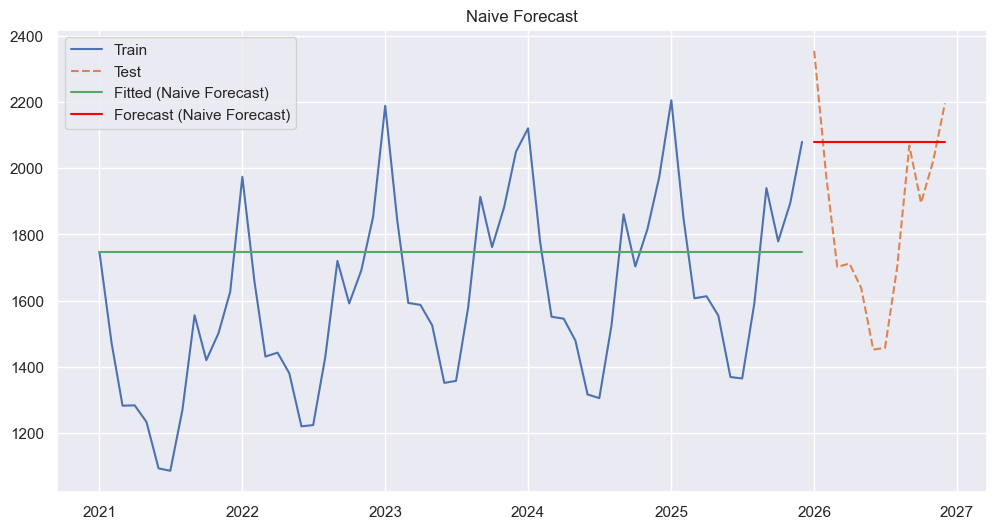

In [669]:
# 49. Tạo giá trị khớp (Fitted) cho mô hình Naive: 
# Ở đây bạn đang lấy giá trị đầu tiên (tháng 1/2021) và lặp lại cho toàn bộ tập Train. 
# Cách này giúp bạn nhìn thấy doanh số thực tế đã "thoát" ra khỏi mức khởi điểm như thế nào qua các năm.
fitted_naive = np.repeat(train.iloc[0], len(train))

# 50. Gọi hàm vẽ biểu đồ:
# Trực quan hóa để thấy mô hình "ngây ngô" này lệch bao nhiêu so với thực tế của 15 loại bánh.
plot_forecast_model(
    train,
    test,
    fitted_naive,
    pred_naive,
    'Naive Forecast'
)


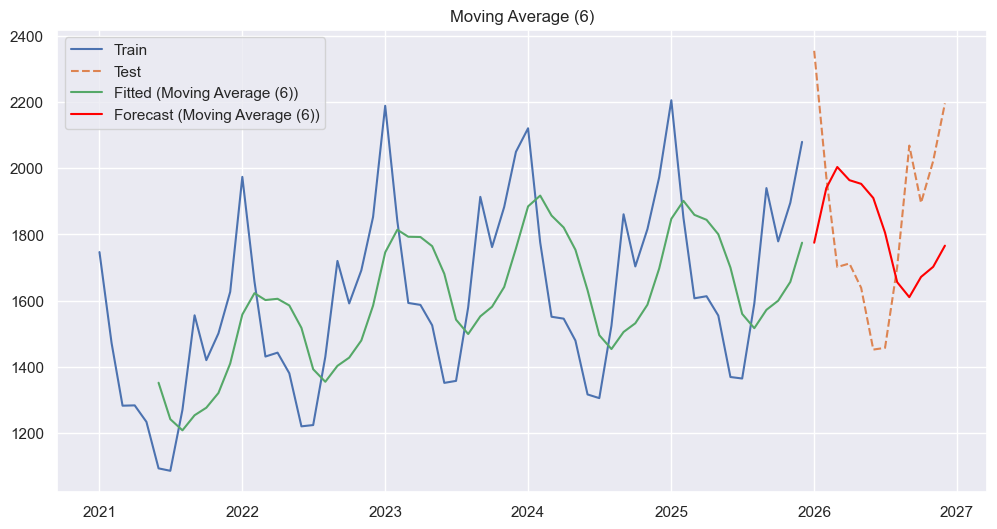

In [671]:
# 51. Tính giá trị khớp (Fitted) cho Moving Average: 
# Sử dụng hàm .rolling(6).mean() để tính trung bình của mỗi cụm 6 tháng liên tiếp trong tập Train.
# Đây là cách để xem trong quá khứ, mô hình này "bám đuổi" dữ liệu thực tế ra sao.
fitted_ma = train.rolling(6).mean()

# 52. Gọi hàm vẽ biểu đồ:
# Trực quan hóa để quan sát hiệu ứng "làm mượt" (smoothing) của mô hình trung bình trượt 6 tháng.
plot_forecast_model(
    train,
    test,
    fitted_ma,
    pred_ma,
    'Moving Average (6)'
)

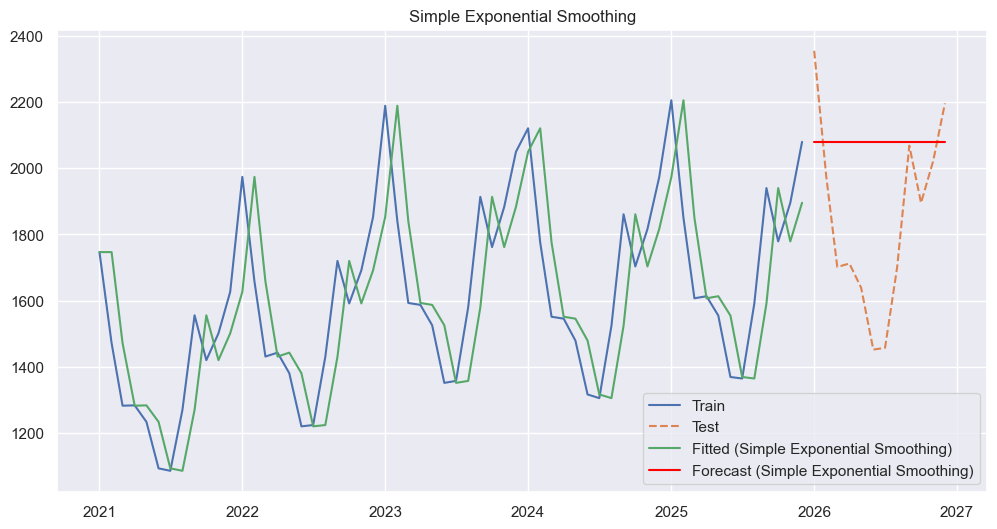

In [673]:
# 53. Sử dụng giá trị Fitted của SES: 
# Khác với Moving Average, ses.fittedvalues chứa các giá trị mà mô hình đã tính toán cho tập Train 
# bằng cách đánh trọng số mũ (ưu tiên dữ liệu gần hiện tại hơn).

# 54. Gọi hàm vẽ biểu đồ:
# Trực quan hóa kết quả để đánh giá khả năng "lọc nhiễu" của phương pháp San phẳng mũ đơn giản.
plot_forecast_model(
    train,
    test,
    ses.fittedvalues,
    pred_ses,
    'Simple Exponential Smoothing'
)

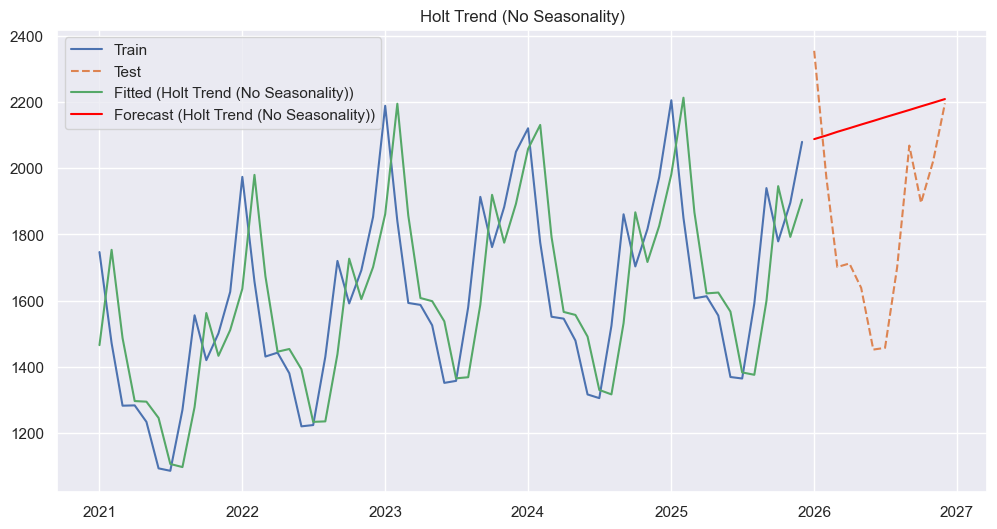

In [674]:
# 55. Trực quan hóa Model 3 – Holt Trend:
# Bước này giúp bạn thấy rõ khả năng nhận diện "đà" tăng trưởng (hoặc sụt giảm) của 15 loại SKU 
# trong suốt giai đoạn 2021-2025.

plot_forecast_model(
    train,
    test,
    holt.fittedvalues, # Giá trị mô hình đã "khớp" được khi tính toán cả Mức độ (Level) và Xu hướng (Trend).
    pred_holt,         # Đường dự báo cho năm 2026 - giờ đây đã là một đường xiên có hướng rõ rệt.
    'Holt Trend (No Seasonality)'
)

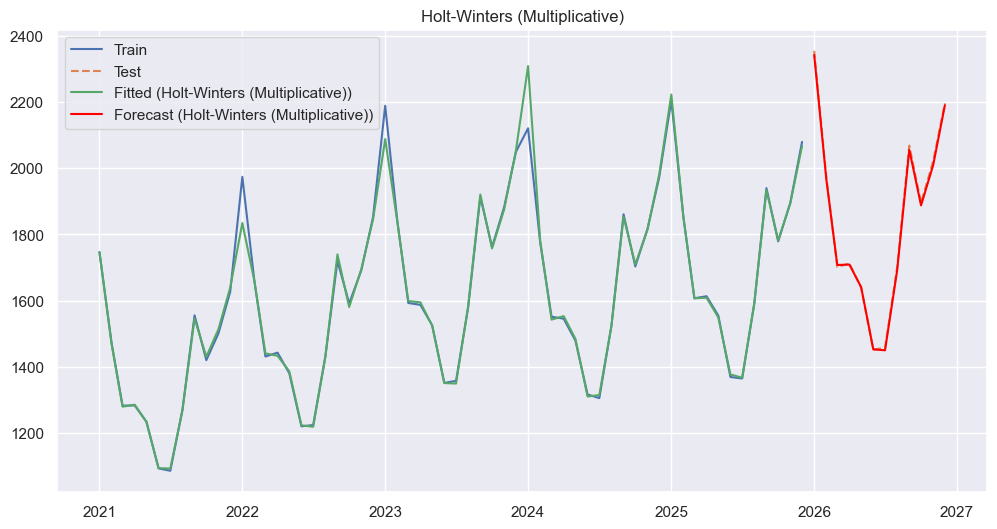

In [677]:
# 56. Trực quan hóa Model 4 – Holt-Winters (Multiplicative):
# Đây là mô hình toàn diện nhất vì nó "bắt" được cả 3 thành phần: Mức độ (Level), Xu hướng (Trend) và đặc biệt là Tính thời vụ (Seasonality).

plot_forecast_model(
    train,
    test,
    hw_mul.fittedvalues, # Giá trị khớp trong quá khứ (2021-2025) bao gồm cả các "đỉnh" và "đáy" thời vụ đã được học.
    pred_hw_mul,         # Đường dự báo cho năm 2026 - giờ đây đã là một đường uốn lượn theo chu kỳ 12 tháng.
    'Holt-Winters (Multiplicative)'
)


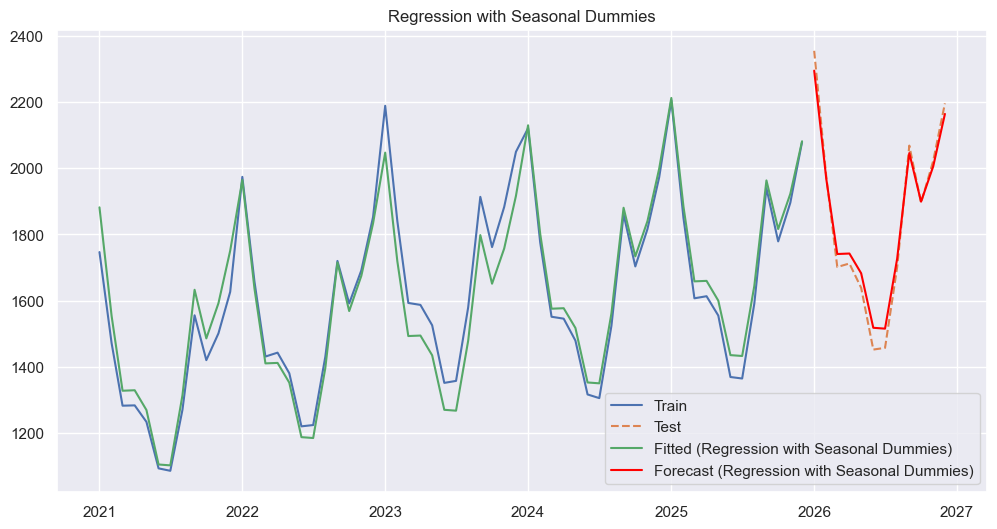

In [679]:
# 57. Tính giá trị khớp (Fitted) cho Hồi quy:
# Sử dụng mô hình đã huấn luyện (lr_season) để dự đoán lại trên tập X_train. 
# Điều này giúp ta xem mô hình hồi quy "khớp" với lịch sử 2021-2025 tốt đến mức nào.
fitted_lr_season = lr_season.predict(X_train)

# 58. Gọi hàm vẽ biểu đồ:
# Trực quan hóa kết quả để so sánh phương pháp hồi quy kinh tế lượng với các mô hình làm mượt mũ trước đó.
plot_forecast_model(
    train,
    test,
    fitted_lr_season,
    pred_lr_season,
    'Regression with Seasonal Dummies'
)

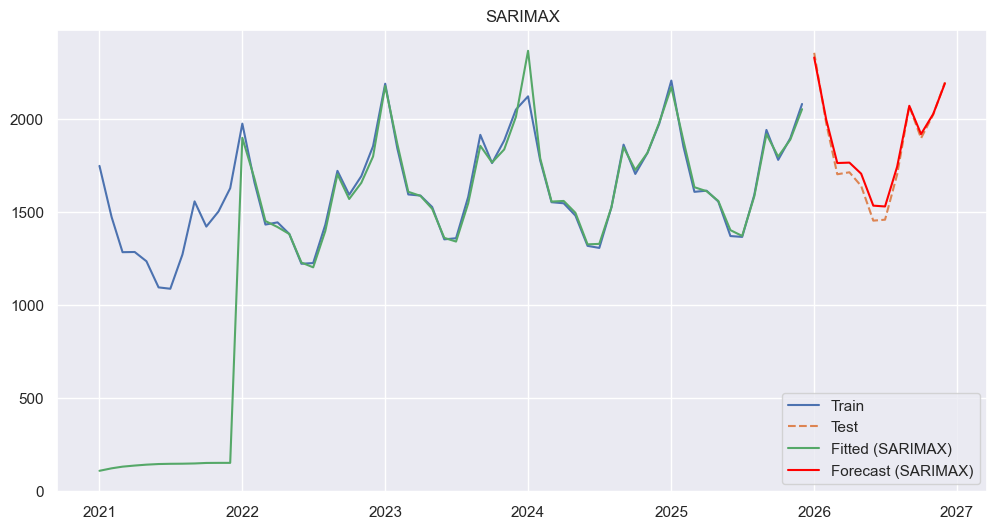

In [680]:
# 59. Trực quan hóa Model 6 – SARIMAX (Seasonal AutoRegressive Integrated Moving Average):
# Đây là mô hình tinh vi nhất vì nó không chỉ học từ xu hướng và mùa vụ, 
# mà còn tự hiệu chỉnh dựa trên những sai số và tương quan của dữ liệu trong quá khứ.

plot_forecast_model(
    train,
    test,
    sarimax.fittedvalues, # Các giá trị mà mô hình SARIMAX đã khớp cực kỳ chi tiết trong giai đoạn 2021-2025.
    pred_sarimax,         # Đường dự báo cho năm 2026 - thường sẽ có độ uốn lượn rất sát với thực tế nếu tham số (p,d,q) chuẩn.
    'SARIMAX'
)

In [683]:
# 60. Huấn luyện mô hình cuối cùng (Final Model Training):
# Sau khi thử nghiệm và chọn được Holt-Winters là mô hình tốt nhất (MAPE thấp nhất), 
# ta tiến hành huấn luyện lại trên TOÀN BỘ dữ liệu (từ 2021 đến hết 2026) thay vì chỉ dùng tập Train.

# 61. Tối ưu hóa tham số cho dự báo tương lai:
final_model = ExponentialSmoothing(
    ts,                   # Sử dụng toàn bộ chuỗi thời gian ts để không bỏ lỡ xu hướng của năm 2026.
    trend='add',          # Giữ nguyên xu hướng cộng dồn để phản ánh đà tăng trưởng của 15 loại sản phẩm.
    seasonal='mul',       # Sử dụng tính thời vụ nhân (Multiplicative) - đặc trưng của ngành hàng bánh kẹo FMCG.
    seasonal_periods=12   # Chu kỳ 12 tháng chuẩn cho một năm tài chính.
).fit()

In [685]:
# 62. Thực hiện dự báo dài hạn (Long-term Forecast):
# Sử dụng mô hình Holt-Winters (Final Model) đã được tối ưu để phóng tầm nhìn ra 72 tháng tiếp theo.

# 63. Kết quả dự báo (2027 - 2032):
# Con số 72 tương ứng với 6 năm tài chính. 
# Điều này giúp bạn lập kế hoạch dài hạn cho năng suất kho bãi và chiến lược cung ứng 15 loại sản phẩm.
forecast_72 = final_model.forecast(72)


In [687]:
# 64. Chuyển đổi chỉ mục (Reset Index):
# Đưa cột ngày tháng từ dạng chỉ mục (Index) về lại thành một cột dữ liệu bình thường.
# Việc này giúp DataFrame trở nên linh hoạt hơn khi bạn muốn thực hiện các thao tác lọc, 
# sắp xếp hoặc kết hợp (join) với các bảng dữ liệu khác.
forecast_df = forecast_72.reset_index()

# 65. Đặt tên cột chuyên nghiệp (Renaming Columns):
# Gán lại tên rõ ràng cho các cột: 'Date' (Thời gian) và 'Forecast_Volume_MT' (Sản lượng dự báo tính bằng Tấn).
# Việc đặt tên cột minh bạch kèm theo đơn vị đo lường là tiêu chuẩn quan trọng 
# giúp người đọc báo cáo hiểu ngay ý nghĩa của các con số mà không cần giải thích thêm.
forecast_df.columns = ['Date', 'Forecast_Volume_MT']

# 66. Hiển thị bảng kết quả dự báo dài hạn:
# Kiểm tra lại 72 dòng dữ liệu (tương ứng 6 năm từ 2027-2032) đã được định dạng chuẩn xác.
forecast_df


,Date,Forecast_Volume_MT
0,2027-01-01,2475.59
1,2027-02-01,2077.29
2,2027-03-01,1801.06
3,2027-04-01,1804.12
4,2027-05-01,1730.65
5,2027-06-01,1532.37
6,2027-07-01,1530.94
7,2027-08-01,1785.68
8,2027-09-01,2169.47
9,2027-10-01,1990.99


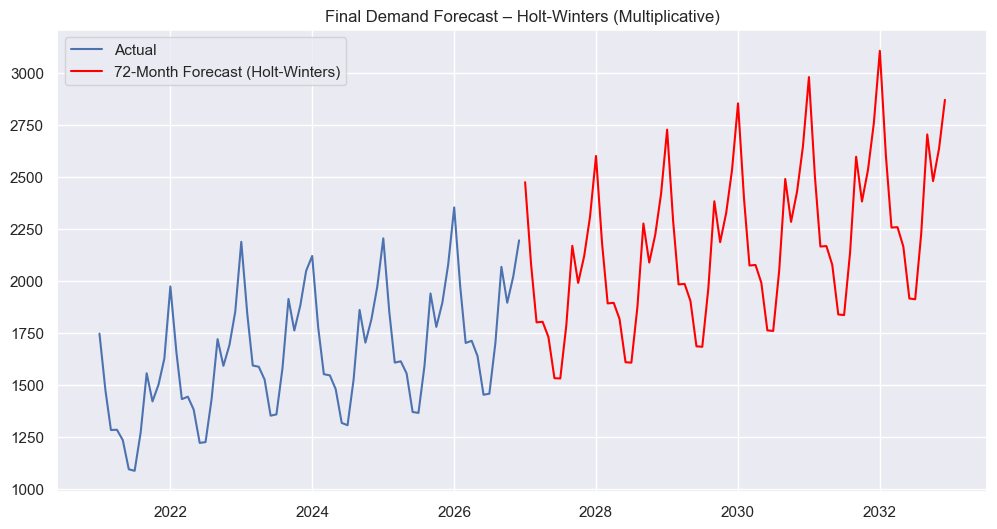

In [689]:
# 67. Khởi tạo khung hình (Plot Initialization):
# Thiết lập kích thước 12x6 để biểu đồ đủ rộng, giúp nhìn rõ các biến động thời vụ trong suốt 12 năm (6 năm lịch sử + 6 năm dự báo).
plt.figure(figsize=(12,6))

# 68. Vẽ dữ liệu thực tế (Actual Data):
# Đường này đại diện cho hành trình doanh số thực tế từ năm 2021 đến cuối năm 2026 của 15 loại SKU.
plt.plot(ts.index, ts.values, label='Actual')

# 69. Vẽ đường dự báo 6 năm (Strategic Forecast):
# Sử dụng màu ĐỎ (Red) để nhấn mạnh phần tương lai (2027-2032). 
# Đây là kết quả từ mô hình Holt-Winters đã học được tính thời vụ nhân (Multiplicative) từ các dòng bánh như Doowee Donut hay Whoopie.
plt.plot(forecast_72.index, forecast_72.values, 
         label='72-Month Forecast (Holt-Winters)', color='red')

# 70. Hoàn thiện biểu đồ:
# Thêm tiêu đề chuyên nghiệp, chú thích (legend) và lưới (grid) để việc so sánh các đỉnh doanh số giữa các năm trở nên dễ dàng hơn.
plt.title('Final Demand Forecast – Holt-Winters (Multiplicative)')
plt.legend()
plt.grid(True)
plt.show()

In [691]:
# 71. Phân nhóm theo Thương hiệu (Brand-level Aggregation):
# Thay vì nhìn vào bức tranh tổng thể, ta bắt đầu "mổ xẻ" dữ liệu để xem sản lượng (Volume MT) 
# biến thiên thế nào cho từng thương hiệu cụ thể (như Doowee Donut hay Whoopie) qua thời gian.

brand_ts = (
    df
    .groupby(['Brand', 'Date'])['Volume (MT)']
    .sum() # Tính tổng sản lượng của tất cả các SKU thuộc cùng một thương hiệu trong mỗi tháng.
    .reset_index() # Chuyển kết quả từ dạng GroupBy về lại DataFrame phẳng để dễ dàng xử lý và vẽ biểu đồ ở các bước sau.
)

In [693]:
# 72. Khởi tạo danh sách lưu trữ: Nơi chứa kết quả dự báo của từng thương hiệu.
brand_forecasts = []

# 73. Vòng lặp tự động cho từng Thương hiệu:
# Thay vì viết code 15 lần cho 15 thương hiệu, ta dùng vòng lặp để xử lý hàng loạt.
for brand in brand_ts['Brand'].unique():
    
    # 74. Trích xuất chuỗi thời gian cho từng Brand:
    ts_brand = (
        brand_ts[brand_ts['Brand'] == brand]
        .set_index('Date')['Volume (MT)']
        .asfreq('MS') # Đảm bảo dữ liệu liên tục theo từng tháng (Monthly Start).
    )
    
    # 75. Điều kiện lọc dữ liệu (Data Quality Gate):
    # Một quy tắc quan trọng trong Business Analytics: Để dự báo mùa vụ (12 tháng), 
    # ta cần ít nhất 2 chu kỳ (24 tháng) để mô hình "học" được quy luật lặp lại.
    if len(ts_brand.dropna()) < 24:
        continue # Bỏ qua những thương hiệu quá mới hoặc quá ít dữ liệu để tránh sai số lớn.
    
    # 76. Huấn luyện mô hình Holt-Winters cho từng Brand:
    # Mỗi thương hiệu sẽ có bộ hệ số (Alpha, Beta, Gamma) riêng biệt phù hợp với nó.
    model = ExponentialSmoothing(
        ts_brand,
        trend='add',
        seasonal='mul',
        seasonal_periods=12
    ).fit()
    
    # 77. Dự báo 72 tháng tương lai:
    fc = model.forecast(72)
    
    # 78. Chuẩn hóa kết quả dự báo:
    fc_df = fc.reset_index()
    fc_df.columns = ['Date', 'Forecast_Volume_MT']
    fc_df['Brand'] = brand # Gắn nhãn thương hiệu để không bị nhầm lẫn khi gộp bảng.
    
    brand_forecasts.append(fc_df)


In [694]:
# 79. Hợp nhất kết quả (Data Consolidation):
# Sử dụng pd.concat để "xếp chồng" các bảng dự báo riêng lẻ của từng thương hiệu lại với nhau.
# Kết quả là một DataFrame duy nhất chứa lộ trình 6 năm tới cho mọi Brand đủ điều kiện.

forecast_brand_df = pd.concat(brand_forecasts)

# 80. Kiểm tra bảng dữ liệu tổng hợp:
# Đảm bảo dữ liệu ở dạng "Tidy Data" (mỗi dòng là một quan sát: một tháng - một thương hiệu - một giá trị dự báo).
forecast_brand_df

,Date,Forecast_Volume_MT,Brand
0,2027-01-01,701.38,Doowee Donut
1,2027-02-01,603.44,Doowee Donut
2,2027-03-01,449.44,Doowee Donut
3,2027-04-01,451.30,Doowee Donut
4,2027-05-01,450.18,Doowee Donut
5,2027-06-01,451.11,Doowee Donut
6,2027-07-01,450.81,Doowee Donut
7,2027-08-01,500.98,Doowee Donut
8,2027-09-01,549.60,Doowee Donut
9,2027-10-01,499.64,Doowee Donut


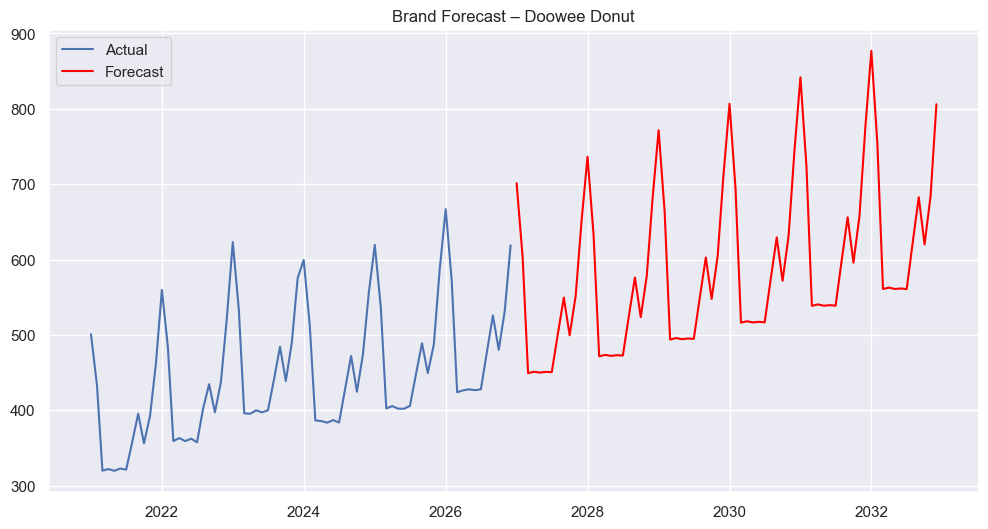

In [697]:
# 81. Lựa chọn thương hiệu kiểm tra:
# Lấy tên thương hiệu đầu tiên trong danh sách dự báo để vẽ biểu đồ mẫu. 
# Bạn có thể thay đổi số 0 bằng các chỉ số khác để kiểm tra các loại bánh khác nhau.
brand = forecast_brand_df['Brand'].iloc[0]

plt.figure(figsize=(12,6))

# 82. Vẽ dữ liệu thực tế (Actual) của Thương hiệu:
# Lọc dữ liệu lịch sử từ bảng brand_ts chỉ dành riêng cho thương hiệu này.
plt.plot(
    brand_ts[brand_ts['Brand']==brand]['Date'],
    brand_ts[brand_ts['Brand']==brand]['Volume (MT)'],
    label='Actual'
)

# 83. Vẽ dữ liệu dự báo (Forecast) của Thương hiệu:
# Đường màu ĐỎ thể hiện kỳ vọng sản lượng trong 6 năm tới (2027-2032).
# Đây là "la bàn" để bạn lập kế hoạch thu mua nguyên liệu cho thương hiệu cụ thể này.
plt.plot(
    forecast_brand_df[forecast_brand_df['Brand']==brand]['Date'],
    forecast_brand_df[forecast_brand_df['Brand']==brand]['Forecast_Volume_MT'],
    label='Forecast', color='red'
)

# 84. Hoàn thiện biểu đồ:
# Tên biểu đồ sẽ tự động thay đổi theo thương hiệu được chọn nhờ sử dụng f-string.
plt.title(f'Brand Forecast – {brand}')
plt.legend()
plt.grid(True)
plt.show()


In [699]:
# 85. Tạo mã định danh SKU duy nhất (Option B – Granular Level):
# Thay vì chỉ dự báo theo Thương hiệu, ta đi sâu vào từng biến thể sản phẩm cụ thể. 
# Việc kết hợp Brand | Product Name | Pack Size giúp đảm bảo không có sự nhầm lẫn giữa các quy cách đóng gói.

df['SKU'] = (
    df['Brand'] + ' | ' +
    df['Product Name'] + ' | ' +
    df['Pack Size']
)

# Ví dụ: "Brand A | Bánh Donut Socola | Gói 6 cái" sẽ là một chuỗi thời gian riêng biệt.

In [701]:
# 85. Tổng hợp dữ liệu ở cấp độ SKU (Aggregation):
# Sau khi đã tạo mã SKU (kết hợp từ Brand, Product Name và Pack Size), 
# ta tiến hành gom nhóm để tính tổng sản lượng (Volume MT) cho từng mã hàng theo từng tháng.

sku_ts = (
    df
    .groupby(['SKU', 'Date'])['Volume (MT)']
    .sum()
    .reset_index() # Chuyển kết quả về dạng bảng dọc (Long format) để sẵn sàng cho vòng lặp dự báo.
)

In [703]:
# 86. Khởi tạo danh sách kết quả SKU: Nơi lưu trữ "vương quốc" dữ liệu dự báo cho từng mã hàng.
sku_forecasts = []

# 87. Vòng lặp tự động hóa (Automated Pipeline): 
# Hệ thống sẽ tự động quét qua hàng chục, hàng trăm SKU để tìm ra quy luật riêng của từng loại bao bì.
for sku in sku_ts['SKU'].unique():
    
    # 88. Trích xuất và định dạng chuỗi thời gian:
    ts_sku = (
        sku_ts[sku_ts['SKU'] == sku]
        .set_index('Date')['Volume (MT)']
        .asfreq('MS') # Thiết lập tần suất hàng tháng để mô hình nhận diện tính thời vụ.
    )
    
    # 89. Rule thực tế - "Người gác cổng" dữ liệu:
    # Trong SCM, dự báo mùa vụ (12 tháng) cần tối thiểu 2 chu kỳ đầy đủ (24 tháng) để đảm bảo độ tin cậy. 
    # Việc loại bỏ các SKU "non trẻ" giúp tránh sai số ảo làm lệch kế hoạch cung ứng.
    if len(ts_sku.dropna()) < 24:
        continue
    
    # 90. Triển khai Holt-Winters cho từng SKU:
    # Mô hình tự động tính toán các hệ số tối ưu cho từng loại bánh và quy cách đóng gói cụ thể.
    model = ExponentialSmoothing(
        ts_sku,
        trend='add',
        seasonal='mul',
        seasonal_periods=12
    ).fit()
    
    # 91. Phóng tầm nhìn 6 năm (72 tháng):
    # Tạo ra lộ trình dài hạn giúp bộ phận sản xuất và kho bãi chủ động hơn trong tương lai.
    fc = model.forecast(72)
    
    # 92. Gắn nhãn và đóng gói dữ liệu:
    fc_df = fc.reset_index()
    fc_df.columns = ['Date', 'Forecast_Volume_MT']
    fc_df['SKU'] = sku # Đánh dấu "tên tuổi" cho từng dòng dự báo.
    
    sku_forecasts.append(fc_df)


In [704]:
# 93. Hợp nhất kết quả (Data Consolidation):
# Gom tất cả các DataFrame dự báo riêng lẻ trong danh sách 'sku_forecasts' thành một bảng tổng duy nhất.
# Việc gộp này giúp bạn có cái nhìn toàn cảnh về nhu cầu của tất cả các biến thể bao bì bánh.
forecast_sku_df = pd.concat(sku_forecasts, ignore_index=True)

# 94. Cấu hình hiển thị Pandas (Pandas Display Options):
# Khi làm Analytics, đôi khi ta cần soi kỹ từng con số. Các thiết lập này giúp bạn kiểm soát 
# việc hiển thị dữ liệu trong Notebook một cách tuyệt đối.

# a. Hiển thị toàn bộ nội dung cột: Đảm bảo các tên SKU dài (gồm Brand | Name | Size) không bị ẩn.
pd.set_option('display.max_colwidth', None)

# b. Hiển thị tất cả các dòng: Giúp bạn cuộn xem trọn vẹn lộ trình 72 tháng của tất cả sản phẩm.
pd.set_option('display.max_rows', None)

# c. Hiển thị tất cả các cột: Tránh việc các tháng ở giữa bị thay thế bằng dấu ba chấm.
pd.set_option('display.max_columns', None)

# 95. Xuất bảng kiểm tra: "Full không che" để rà soát sai số lần cuối.
forecast_sku_df

,Date,Forecast_Volume_MT,SKU
0,2027-01-01,140.39,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
1,2027-02-01,120.80,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
2,2027-03-01,90.61,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
3,2027-04-01,91.00,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
4,2027-05-01,89.81,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
5,2027-06-01,90.09,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
6,2027-07-01,91.13,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
7,2027-08-01,100.27,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
8,2027-09-01,110.32,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)
9,2027-10-01,100.11,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g)


In [707]:
# 96. Trích xuất Năm (Year Extraction):
# Tạo thêm cột 'Year' để dễ dàng thực hiện các báo cáo so sánh tăng trưởng hàng năm (Year-over-Year).
forecast_brand_df['Year'] = forecast_brand_df['Date'].dt.year

# 97. Phân nhóm theo Quý (Quarterly Mapping):
# Sử dụng .to_period('Q') để gom các tháng lại thành từng Quý (ví dụ: 2027Q1, 2027Q2...).
# Việc chuyển sang dạng chuỗi (string) giúp bảng dữ liệu trông gọn gàng và dễ đọc hơn khi xuất báo cáo.
forecast_brand_df['Quarter'] = forecast_brand_df['Date'].dt.to_period('Q').astype(str)

In [709]:
# 98. Tạo nhãn Quý rút gọn (Short Quarter Labeling):
# Lệnh này trích xuất số thứ tự quý (1-4) và đính kèm chữ 'Q' phía trước.
# Mục đích: Tạo ra các nhóm định danh như Q1, Q2, Q3, Q4 để phân tích đặc tính 
# biến động định kỳ của 15 loại sản phẩm qua các năm.

forecast_brand_df['Quarter'] = 'Q' + forecast_brand_df['Date'].dt.quarter.astype(str)

In [713]:
# 99. Tổng hợp dự báo theo Năm (Annual Aggregation):
# Gom nhóm dữ liệu theo từng Thương hiệu và từng Năm để tính tổng sản lượng dự báo (MT).
# Đây là con số quan trọng nhất cho việc lập kế hoạch ngân sách và đầu tư dài hạn.

forecast_year_brand = (
    forecast_brand_df
    .groupby(['Brand', 'Year'])['Forecast_Volume_MT']
    .sum() # Tính tổng sản lượng của cả 12 tháng trong năm.
    .reset_index()
)

# 100. Kiểm tra bảng dự báo năm:
# Giúp bạn nhìn thấy tốc độ tăng trưởng hàng năm (YoY Growth) của từng thương hiệu.
forecast_year_brand


,Brand,Year,Forecast_Volume_MT
0,Doowee Donut,2027,6310.19
1,Doowee Donut,2028,6619.24
2,Doowee Donut,2029,6928.28
3,Doowee Donut,2030,7237.33
4,Doowee Donut,2031,7546.38
5,Doowee Donut,2032,7855.42
6,KrimStix,2027,8179.81
7,KrimStix,2028,8561.24
8,KrimStix,2029,8942.67
9,KrimStix,2030,9324.09


In [715]:
# 101. Tổng hợp dự báo theo Quý (Quarterly Aggregation):
# Gom nhóm dữ liệu theo ba cấp độ: Thương hiệu -> Năm -> Quý.
# Điều này giúp bạn xác định được "điểm rơi" sản lượng trong năm 2027-2032.

forecast_quarter_brand = (
    forecast_brand_df
    .groupby(['Brand', 'Year', 'Quarter'])['Forecast_Volume_MT']
    .sum()
    .reset_index()
    # 102. Sắp xếp dữ liệu (Sorting):
    # Đảm bảo dữ liệu hiển thị theo đúng trình tự thời gian và tên thương hiệu, 
    # giúp việc theo dõi đà tăng trưởng không bị ngắt quãng.
    .sort_values(['Brand', 'Year', 'Quarter'])
)

# 103. Hiển thị bảng kết quả: 
# Bảng này sẽ là dữ liệu nền hoàn hảo cho các phân tích tính thời vụ chuyên sâu.
forecast_quarter_brand


,Brand,Year,Quarter,Forecast_Volume_MT
0,Doowee Donut,2027,Q1,1754.26
1,Doowee Donut,2027,Q2,1352.59
2,Doowee Donut,2027,Q3,1501.39
3,Doowee Donut,2027,Q4,1701.95
4,Doowee Donut,2028,Q1,1841.82
5,Doowee Donut,2028,Q2,1419.23
6,Doowee Donut,2028,Q3,1574.43
7,Doowee Donut,2028,Q4,1783.76
8,Doowee Donut,2029,Q1,1929.37
9,Doowee Donut,2029,Q2,1485.87


In [717]:
# 104. Tạo Bảng Pivot Chiến lược (Strategic Pivot Table):
# Chuyển đổi cấu trúc dữ liệu để phục vụ việc so sánh đối chiếu giữa các Thương hiệu.

pivot_year_brand = forecast_year_brand.pivot(
    index='Year',      # Mỗi hàng đại diện cho một năm (từ 2027 - 2032).
    columns='Brand',   # Mỗi cột đại diện cho một Thương hiệu (ví dụ: Doowee Donut, Whoopie...).
    values='Forecast_Volume_MT' # Giá trị trong mỗi ô là tổng sản lượng dự báo tính bằng Tấn.
)

# 105. Hiển thị bảng kết quả:
# Bảng này giúp bạn nhìn thấy sự phân bổ "thị phần nội bộ" giữa các sản phẩm qua từng năm.
pivot_year_brand

Brand,Doowee Donut,KrimStix,Rebisco Crackers,Rebisco Extreme,Whoopie
Year,,,,,
2027,6310.19,8179.81,3592.45,3977.11,1232.63
2028,6619.24,8561.24,3772.91,4169.50,1292.89
2029,6928.28,8942.67,3953.37,4361.90,1353.14
2030,7237.33,9324.09,4133.82,4554.29,1413.39
2031,7546.38,9705.52,4314.28,4746.68,1473.65
2032,7855.42,10086.95,4494.74,4939.07,1533.90


In [719]:
# 106. Tạo Bảng Pivot theo Quý (Quarterly Multi-Index Pivot):
# Đây là bước nâng cấp từ bảng Năm. Việc sử dụng đồng thời ['Year', 'Quarter'] làm index 
# giúp bạn giữ được sự mạch lạc của thời gian trong khi vẫn gom nhóm được dữ liệu.

pivot_q_brand = forecast_quarter_brand.pivot(
    index=['Year', 'Quarter'], # Tạo cấu trúc phân cấp: Năm bao trùm các Quý.
    columns='Brand',           # Trải dài 15 thương hiệu thành các cột để dễ so sánh đối đầu.
    values='Forecast_Volume_MT' # Giá trị dự báo sản lượng đã được làm sạch và tối ưu.
)

# 107. Hiển thị bảng "Quarterly Strategy Map":
# Bảng này cho phép bạn soi chi tiết: "Quý 4 năm 2028, thương hiệu nào sẽ bùng nổ nhất?".
pivot_q_brand

Brand         Doowee Donut  KrimStix  Rebisco Crackers  Rebisco Extreme  \
Year Quarter                                                              
2027 Q1            1754.26   2068.82           1075.22          1108.46   
     Q2            1352.59   1867.00            725.68           850.14   
     Q3            1501.39   1922.90            811.39           947.16   
     Q4            1701.95   2321.09            980.17          1071.36   
2028 Q1            1841.82   2167.05           1130.28          1163.09   
     Q2            1419.23   1954.66            762.34           891.50   
     Q3            1574.43   2012.01            851.85           992.68   
     Q4            1783.76   2427.52           1028.44          1122.24   
2029 Q1            1929.37   2265.28           1185.33          1217.72   
     Q2            1485.87   2042.31            799.00           932.87   
     Q3            1647.48   2101.12            892.32          1038.20   
     Q4            1865.56   2533.95           1076.72          1173.11   
2030 Q1            2016.93   2363.51           1240.39          1272.35   
     Q2            1552.51   2129.97            835.66           974.23   
     Q3            1720.53   2190.23            932.79          1083.72   
     Q4            1947.36   2640.38           1124.99          1223.99   
2031 Q1            2104.49   2461.74           1295.45          1326.98   
     Q2            1619.14   2217.63            872.32          1015.60   
     Q3            1793.58   2279.34            973.25          1129.24   
     Q4            2029.17   2746.81           1173.26          1274.86   
2032 Q1            2192.04   2559.97           1350.51          1381.61   
     Q2            1685.78   2305.28            908.97          1056.97   
     Q3            1866.63   2368.45           1013.72          1174.76   
     Q4            2110.97   2853.24           1221.54          1325.74   

Brand         Whoopie  
Year Quarter           
2027 Q1        342.10  
     Q2        264.10  
     Q3        293.77  
     Q4        332.66  
2028 Q1        359.14  
     Q2        277.09  
     Q3        308.03  
     Q4        348.62  
2029 Q1        376.18  
     Q2        290.07  
     Q3        322.30  
     Q4        364.58  
2030 Q1        393.23  
     Q2        303.06  
     Q3        336.56  
     Q4        380.54  
2031 Q1        410.27  
     Q2        316.05  
     Q3        350.83  
     Q4        396.50  
2032 Q1        427.31  
     Q2        329.03  
     Q3        365.10  
     Q4        412.46

In [723]:
# 108. Thiết lập SKU Granularity (Độ chi tiết cấp độ SKU):
# Thay vì dự báo chung cho cả thương hiệu, ta "chẻ" dữ liệu xuống mức thấp nhất.
# Việc kết hợp Brand, Product Name và Pack Size giúp mô hình nhận diện được 
# sự khác biệt giữa các dòng sản phẩm cùng loại nhưng khác quy cách đóng gói.

df['SKU'] = (
    df['Brand'] + ' | ' +
    df['Product Name'] + ' | ' +
    df['Pack Size']
)

# 109. Ý nghĩa của dấu ngăn cách ' | ':
# Sử dụng ký tự đặc biệt giúp bạn dễ dàng tách (split) các thành phần này ra 
# thành các cột riêng lẻ sau khi đã hoàn tất dự báo, phục vụ cho việc lọc dữ liệu.

In [725]:
# 110. Lọc dữ liệu 12 tháng gần nhất:
# Sử dụng pd.DateOffset để lấy mốc thời gian lùi lại đúng 1 năm từ ngày gần nhất trong dữ liệu.
# Đây là "tiêu chuẩn vàng" để tính tỷ trọng Mix vì nó trung hòa được các biến động thời vụ hàng tháng.
last_12m = df[df['Date'] >= df['Date'].max() - pd.DateOffset(months=12)]

# 111. Tổng hợp sản lượng theo Brand và SKU:
# Bước này gom nhóm để biết trong 1 năm qua, mỗi SKU (ví dụ: gói 6 cái) đóng góp bao nhiêu tấn vào thương hiệu đó.
mix_df = (
    last_12m
    .groupby(['Brand', 'SKU'])['Volume (MT)']
    .sum()
    .reset_index()
)

# 112. Tính toán tỷ trọng (Mix Calculation):
# Sử dụng .transform('sum') là một kỹ thuật Pandas nâng cao giúp bạn chia sản lượng của từng SKU 
# cho tổng sản lượng của cả thương hiệu đó mà không cần phải thực hiện lệnh merge phức tạp.
mix_df['Mix'] = (
    mix_df['Volume (MT)'] /
    mix_df.groupby('Brand')['Volume (MT)'].transform('sum')
)

# 113. Hiển thị bảng Mix:
# Bảng này cho biết "cấu trúc gene" của từng thương hiệu sản phẩm.
mix_df

,Brand,SKU,Volume (MT),Mix
0,Doowee Donut,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g),1320.19,0.20
1,Doowee Donut,Doowee Donut | Doowee Donut Chocolate | Polybag (6 x 30g),657.87,0.10
2,Doowee Donut,Doowee Donut | Doowee Donut Chocolate | Single Pack (30g),2319.11,0.35
3,Doowee Donut,Doowee Donut | Doowee Donut Strawberry | Polybag (6 x 30g),659.72,0.10
4,Doowee Donut,Doowee Donut | Doowee Donut Strawberry | Single Pack (30g),1637.27,0.25
5,KrimStix,KrimStix | KrimStix Chocolate | Jar (100 sticks),3378.45,0.40
6,KrimStix,KrimStix | KrimStix Chocolate | Pouch (20 sticks),1270.18,0.15
7,KrimStix,KrimStix | KrimStix Combo | Party Bucket (60 sticks),422.56,0.05
8,KrimStix,KrimStix | KrimStix Milk | Jar (100 sticks),2532.05,0.30
9,KrimStix,KrimStix | KrimStix Peanut Butter | Pouch (20 sticks),847.50,0.10


In [726]:
# 114. Kiểm tra tính toàn vẹn của dữ liệu (Sanity Check):
# Trong phân tích dữ liệu, tổng các thành phần (Mix) của một nhóm phải luôn bằng 1.0 (tương đương 100%).

# 115. Xác nhận logic Groupby:
# Việc chạy dòng lệnh này giúp bạn khẳng định rằng hàm .transform('sum') ở bước trước 
# đã hoạt động chính xác cho từng Brand riêng biệt.
mix_df.groupby('Brand')['Mix'].sum()

# Kết quả ≈ 1.0 là "tín hiệu xanh" để bạn tự tin đi tiếp.

Brand
Doowee Donut        1.0
KrimStix            1.0
Rebisco Crackers    1.0
Rebisco Extreme     1.0
Whoopie             1.0
Name: Mix, dtype: float64

In [729]:
# 116. Hợp nhất dữ liệu (Merging Forecast & Mix):
# Kết hợp bảng dự báo Brand với bảng tỷ trọng Mix. 
# Phép 'left' merge sẽ nhân bản các dòng dự báo cho từng SKU thuộc Brand đó.
alloc_df = forecast_brand_df.merge(
    mix_df[['Brand', 'SKU', 'Mix']],
    on='Brand',
    how='left'
)

# 117. Tính toán dự báo cấp SKU (SKU Allocation):
# Áp dụng công thức phân bổ sản lượng dựa trên hành vi tiêu dùng 12 tháng gần nhất.
alloc_df['Forecast_SKU_MT'] = (
    alloc_df['Forecast_Volume_MT'] * alloc_df['Mix']
)

# 118. Kiểm tra kết quả:
# Giờ đây bạn đã có con số dự báo cụ thể cho từng loại gói (Pack Size) của mỗi sản phẩm.
alloc_df

,Date,Forecast_Volume_MT,Brand,Year,Quarter,SKU,Mix,Forecast_SKU_MT
0,2027-01-01,701.38,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g),0.20,140.42
1,2027-01-01,701.38,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Chocolate | Polybag (6 x 30g),0.10,69.97
2,2027-01-01,701.38,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Chocolate | Single Pack (30g),0.35,246.67
3,2027-01-01,701.38,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Strawberry | Polybag (6 x 30g),0.10,70.17
4,2027-01-01,701.38,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Strawberry | Single Pack (30g),0.25,174.15
5,2027-02-01,603.44,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Assorted | Family Box (12 x 30g),0.20,120.81
6,2027-02-01,603.44,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Chocolate | Polybag (6 x 30g),0.10,60.20
7,2027-02-01,603.44,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Chocolate | Single Pack (30g),0.35,212.23
8,2027-02-01,603.44,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Strawberry | Polybag (6 x 30g),0.10,60.37
9,2027-02-01,603.44,Doowee Donut,2027,Q1,Doowee Donut | Doowee Donut Strawberry | Single Pack (30g),0.25,149.83


In [730]:
# 119. Đối soát tổng sản lượng (Forecast Reconciliation):
# Sau khi phân bổ từ Brand xuống SKU, ta cần gộp ngược lại để kiểm tra xem 
# tổng dự báo của các SKU có bằng đúng con số dự báo Brand ban đầu hay không.

# 120. Làm tròn và hiển thị kết quả:
# Sử dụng .round(2) để dễ dàng đối chiếu mắt thường và loại bỏ các sai số nhỏ 
# do tính toán số thực (floating-point) của máy tính.
alloc_df.groupby(['Brand', 'Date'])['Forecast_SKU_MT'].sum().round(2)

# Nếu con số này khớp với 'Forecast_Volume_MT' ở bước 107, 
# thì thuật toán của bạn đã đạt độ chính xác tuyệt đối về mặt logic!

Brand             Date      
Doowee Donut      2027-01-01     701.38
                  2027-02-01     603.44
                  2027-03-01     449.44
                  2027-04-01     451.30
                  2027-05-01     450.18
                  2027-06-01     451.11
                  2027-07-01     450.81
                  2027-08-01     500.98
                  2027-09-01     549.60
                  2027-10-01     499.64
                  2027-11-01     551.88
                  2027-12-01     650.43
                  2028-01-01     736.51
                  2028-02-01     633.54
                  2028-03-01     471.76
                  2028-04-01     473.63
                  2028-05-01     472.36
                  2028-06-01     473.24
                  2028-07-01     472.84
                  2028-08-01     525.36
                  2028-09-01     576.23
                  2028-10-01     523.76
                  2028-11-01     578.41
                  2028-12-01     681.58
           

In [731]:
# 121 Kiểm tra xem có dòng nào bị lệch không (kết quả nên là một bảng toàn số 0)
check_diff = (
    alloc_df.groupby(['Brand', 'Date'])['Forecast_SKU_MT'].sum() - 
    forecast_brand_df.set_index(['Brand', 'Date'])['Forecast_Volume_MT']
).round(4)

print(f"Tổng sai lệch: {check_diff.sum()}")

Tổng sai lệch: 0.0


In [736]:
# 1. Kiểm tra cấu trúc & kiểu dữ liệu
df.info()

# 2. Xem thống kê các biến số
df.describe()

# 3. Kỹ thuật Feature Engineering: Tạo trục thời gian chuẩn
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01'
)

# 4. Sắp xếp để biểu đồ không bị rối
df = df.sort_values('Date')


<class 'pandas.core.frame.DataFrame'>
Index: 1656 entries, 0 to 1655
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Year          1656 non-null   int64         
 1   Month         1656 non-null   int64         
 2   Brand         1656 non-null   object        
 3   Product Name  1656 non-null   object        
 4   Pack Size     1656 non-null   object        
 5   Volume (MT)   1656 non-null   float64       
 6   Date          1656 non-null   datetime64[ns]
 7   SKU           1656 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 116.4+ KB


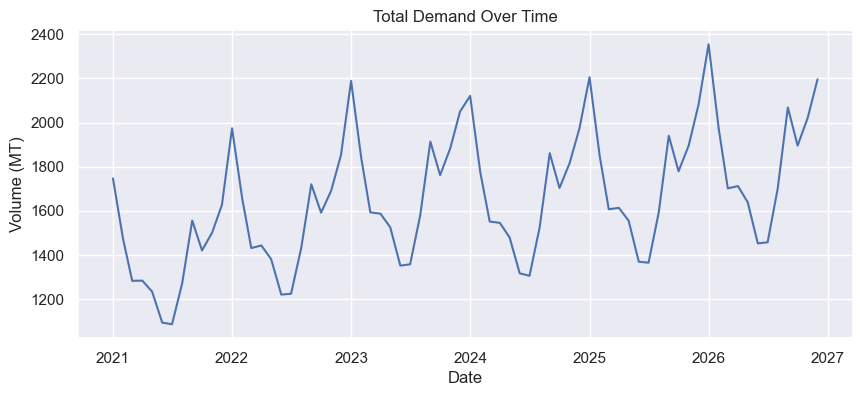

In [738]:
# 5. Gom nhóm theo ngày và tính tổng khối lượng
ts_total = (
    df.groupby('Date')['Volume (MT)']
    .sum()
)

# 6. Thiết lập kích thước khung hình
plt.figure(figsize=(10,4))

# 7. Vẽ biểu đồ đường
plt.plot(ts_total)

# 8. Thêm chú thích cho rõ ràng
plt.title('Total Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Volume (MT)')

# Hiển thị thành quả
plt.show()


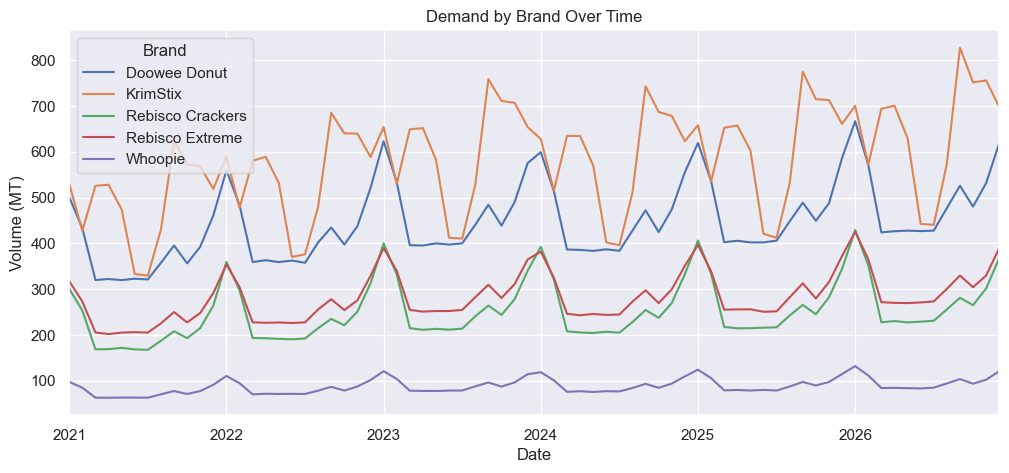

In [740]:
# 9. Gom nhóm theo Ngày & Thương hiệu, sau đó "trải phẳng" Brand ra cột
ts_brand = (
    df.groupby(['Date', 'Brand'])['Volume (MT)']
    .sum()
    .unstack()
)

# 10. Vẽ biểu đồ so sánh đa thương hiệu
ts_brand.plot(figsize=(12,5))

# 11. Ghi chú tiêu đề và đơn vị
plt.title('Demand by Brand Over Time')
plt.ylabel('Volume (MT)')

# Xuất kết quả
plt.show()


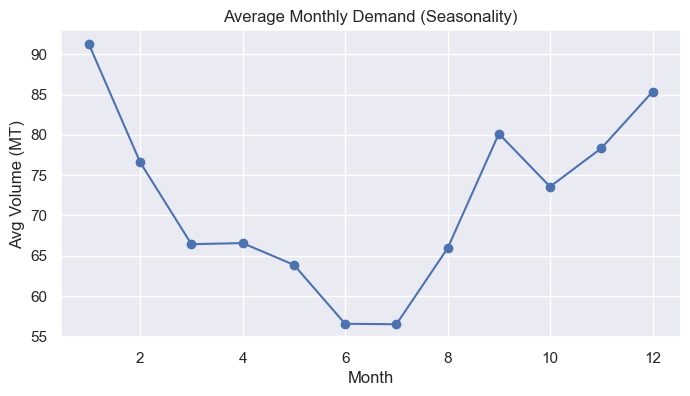

In [742]:
# 12. Tính trung bình khối lượng cho từng tháng (loại bỏ yếu tố năm)
monthly_pattern = (
    df.groupby('Month')['Volume (MT)']
    .mean()
)

# 13. Khởi tạo khung hình & Vẽ biểu đồ có đánh dấu điểm (marker)
plt.figure(figsize=(8,4))
plt.plot(monthly_pattern, marker='o')

# 14. Thêm nhãn dán để hoàn thiện báo cáo
plt.title('Average Monthly Demand (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Avg Volume (MT)')

# Hiển thị
plt.show()

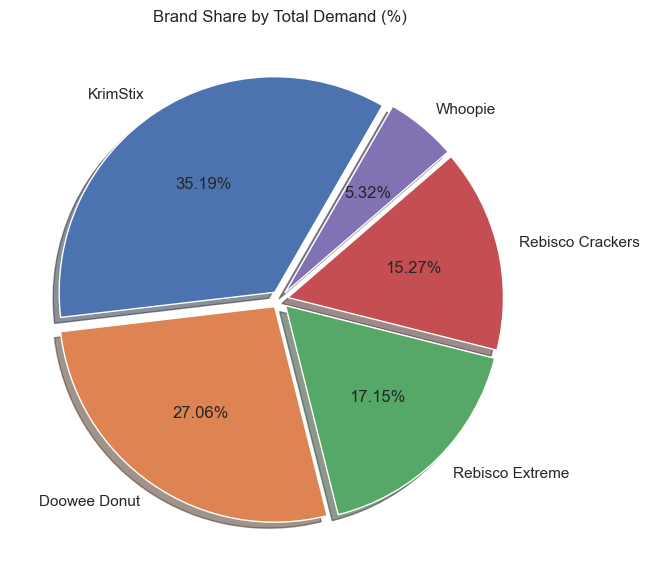

In [744]:
# 15. Tính tổng khối lượng theo Brand và sắp xếp giảm dần
brand_share = (
    df.groupby('Brand')['Volume (MT)']
    .sum()
    .sort_values(ascending=False)
)

# 16. Thiết lập khung hình vuông để hình tròn không bị méo
plt.figure(figsize=(7,7))

# 17. Vẽ biểu đồ tròn với các hiệu ứng thị giác
plt.pie(
    brand_share,
    labels=brand_share.index,
    autopct='%.2f%%',
    startangle=60,
    explode=[0.04] * len(brand_share), # Tách rời các miếng
    shadow=True                        # Đổ bóng 3D
)

plt.title('Brand Share by Total Demand (%)')
plt.show()


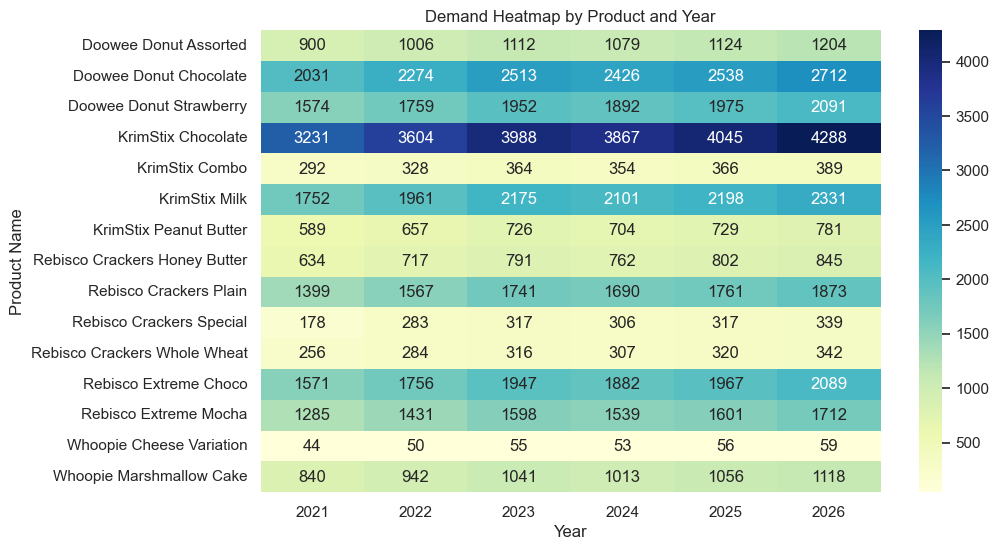

In [746]:
# 18. Tạo ma trận dữ liệu: SKU làm dòng, Năm làm cột
pivot_sku_year = (
    df.groupby(['Product Name', 'Year'])['Volume (MT)']
    .sum()
    .unstack()
)

# 19. Khởi tạo khung hình và vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_sku_year, # Đã sửa lại tên biến cho khớp
    annot=True,     # Hiện số
    fmt=".0f",      # Làm tròn số nguyên
    cmap='YlGnBu'   # Màu Vàng - Xanh
)

# 20. Hoàn thiện tiêu đề
plt.title('Demand Heatmap by Product and Year')
plt.show()

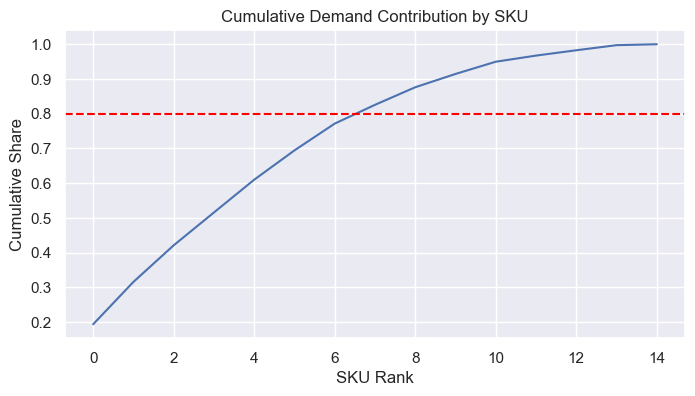

In [747]:
# 21. Tính tổng Volume cho mỗi SKU và xếp hạng từ cao xuống thấp
sku_total = (
    df.groupby('Product Name')['Volume (MT)']
    .sum()
    .sort_values(ascending=False)
)

# 22. Tính % tích lũy (chia tổng tích lũy cho tổng tất cả)
sku_cum = sku_total.cumsum() / sku_total.sum()

# 23. Vẽ biểu đồ Pareto
plt.figure(figsize=(8,4))
plt.plot(sku_cum.values)

# 24. Kẻ đường ngưỡng 80% để phân loại nhóm A
plt.axhline(0.8, color='red', linestyle='--') 

plt.title('Cumulative Demand Contribution by SKU')
plt.ylabel('Cumulative Share')
plt.xlabel('SKU Rank')
plt.show()


In [750]:
# 25. Gom nhóm theo SKU và tính Trung bình & Độ lệch chuẩn
cv_df = (
    df.groupby('Product Name')['Volume (MT)']
    .agg(['mean', 'std'])
)

# 26. Tính chỉ số CV (Hệ số biến thiên)
cv_df['CV'] = cv_df['std'] / cv_df['mean']

# 27. Tìm ra 10 SKU có nhu cầu "bất ổn" nhất
cv_df.sort_values('CV', ascending=False).head(10)


,mean,std,CV
Product Name,,,
Rebisco Crackers Special,24.17,22.72,0.94
Doowee Donut Chocolate,100.65,60.04,0.60
KrimStix Chocolate,159.87,81.08,0.51
Rebisco Extreme Choco,77.86,38.90,0.50
Whoopie Marshmallow Cake,27.83,13.76,0.49
Doowee Donut Strawberry,78.07,36.93,0.47
Rebisco Extreme Mocha,63.65,24.60,0.39
Rebisco Crackers Plain,69.66,14.40,0.21
KrimStix Milk,173.87,35.41,0.20


Trong thực tế, người ta thường dùng $CV$ để chia nhóm XYZ:Nhóm X ($CV < 0.5$): Nhu cầu ổn định, dự báo chính xác cao.Nhóm Y ($0.5 \le CV \le 1.0$): Nhu cầu biến động nhưng vẫn có quy luật (ví dụ: theo mùa).Nhóm Z ($CV > 1.0$): Nhu cầu cực kỳ bất ổn, dự báo rất khó khăn.

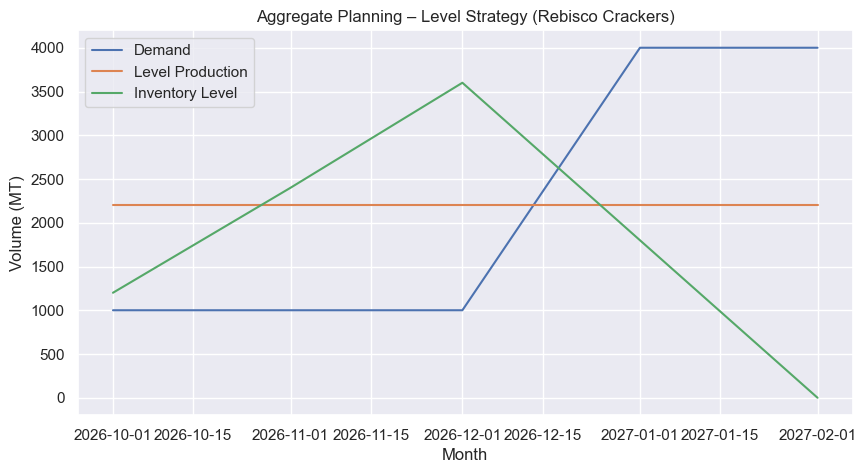

,Month,Demand_MT,Level_Production_MT,Inventory_MT
0,2026-10-01,1000,2200.0,1200.0
1,2026-11-01,1000,2200.0,2400.0
2,2026-12-01,1000,2200.0,3600.0
3,2027-01-01,4000,2200.0,1800.0
4,2027-02-01,4000,2200.0,0.0


In [800]:
#Aggregate Planning analysis for Q9
# Assumptions based on forecast logic (can be adjusted easily)


# -----------------------------
# 1. Create monthly demand profile (Oct 2026 – Feb 2027)
# -----------------------------

months = pd.date_range("2026-10-01", "2027-02-01", freq="MS")

# Assume normal monthly demand for Rebisco Crackers (MT)
base_demand = 1000  

demand = [
    base_demand,          # Oct
    base_demand,          # Nov
    base_demand,          # Dec
    base_demand * 4,      # Jan (300% spike)
    base_demand * 4       # Feb (300% spike)
]

demand_df = pd.DataFrame({
    "Month": months,
    "Demand_MT": demand
})

# -----------------------------
# 2. Level Strategy Production
# -----------------------------

# Produce constant rate from Oct–Dec to cover total demand
total_demand = sum(demand)
level_production_rate = total_demand / len(months)

demand_df["Level_Production_MT"] = level_production_rate

# Inventory calculation
inventory = []
inv = 0
for i in range(len(demand_df)):
    inv += demand_df.loc[i, "Level_Production_MT"] - demand_df.loc[i, "Demand_MT"]
    inventory.append(inv)

demand_df["Inventory_MT"] = inventory

# -----------------------------
# 3. Plot Aggregate Planning Curve
# -----------------------------

plt.figure(figsize=(10,5))
plt.plot(demand_df["Month"], demand_df["Demand_MT"], label="Demand")
plt.plot(demand_df["Month"], demand_df["Level_Production_MT"], label="Level Production")
plt.plot(demand_df["Month"], demand_df["Inventory_MT"], label="Inventory Level")

plt.title("Aggregate Planning – Level Strategy (Rebisco Crackers)")
plt.xlabel("Month")
plt.ylabel("Volume (MT)")
plt.legend()
plt.show()

demand_df


Given the 300% demand surge during Tet and the continuous-operation nature of tunnel ovens, a Level Strategy is recommended.
Producing at a constant rate from October to December allows Rebisco to build sufficient inventory (peak ~3,600 MT) to fully cover Tet demand without relying on costly overtime or energy-intensive production spikes.
While inventory holding costs increase, they are outweighed by savings in overtime, energy, and operational risk, ensuring product availability during the critical festive season.

In [1035]:
# Giả sử chi phí (Assumptions)
unit_cost = 1000 # $ per MT
holding_cost_rate = 0.01 # 1% per month
ot_premium = 1.5 # OT cost is 1.5x regular cost

# 1. Tính chi phí cho Level Strategy
# Chỉ tốn tiền lưu kho (vì sản xuất đều, không có OT)
demand_df['Level_Hold_Cost'] = demand_df['Inventory_MT'] * (unit_cost * holding_cost_rate)
total_level_cost = demand_df['Level_Hold_Cost'].sum()

# 2. Tính chi phí cho Chase Strategy
# Tốn tiền OT cho những tháng sản xuất vượt công suất bình thường (giả sử công suất là 1000MT)
capacity = 1000
demand_df['OT_Volume'] = (demand_df['Demand_MT'] - capacity).clip(lower=0)
demand_df['Chase_OT_Cost'] = demand_df['OT_Volume'] * (unit_cost * (ot_premium - 1))
total_chase_cost = demand_df['Chase_OT_Cost'].sum()

print(f"Total Cost Level Strategy: ${total_level_cost:,.0f}")
print(f"Total Cost Chase Strategy: ${total_chase_cost:,.0f}")


Total Cost Level Strategy: $-68,926
Total Cost Chase Strategy: $1,276,442
